# Pachete necesare pentru folosirea acestui Notebook

Vom folosi [scipy](https://scipy.org/), [numpy](https://numpy.org/) și [matplotlib](https://matplotlib.org/).

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import misc, ndimage, datasets
from scipy.fft import dctn, idctn
from pathlib import Path
import cv2

# Imaginea cu care lucrăm

Vom folosi o imagine din setul de date oferit implicit de către scipy.

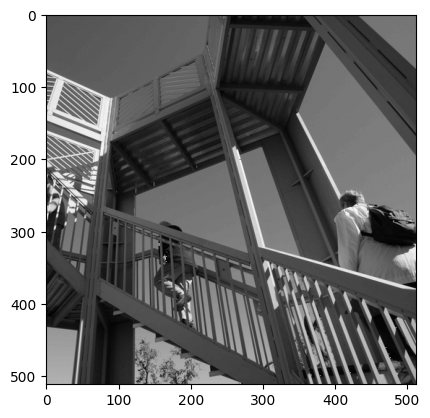

In [3]:
X = datasets.ascent()
plt.imshow(X, cmap=plt.cm.gray)
plt.show()

# Transformata DCT a unei imagini

Transformata DCT se extinde la mai multe dimensiuni similar cu transformata DFT. Pentru un semnal bidimensional, precum o imagine, DCT-II devine:

$$
Y_{m_1,m_2} = \sum_{n_1=0}^{N_1-1}
              \sum_{n_2=0}^{N_2-1}
              x_{n_1,n_2}
              \cos\left[\frac{\pi}{N_1}m_1
                \left(n_1 + \frac12\right)\right]
              \cos\left[\frac{\pi}{N_2}m_2\left(n_2 + \frac12\right)\right]
$$

* unde $n_1$ și $n_2$ sunt pozițile pixelilor pe orizontală, respectiv, pe verticală
* bin-urile rezultate corespund pozițiilor pixelilor
* spectrul este în continuare simetric și par
* proprietățile transformatei DCT-II sunt respectate și în cazul celei 2D

În Python avem rutina `scipy.fft.dct` pentru 1D și `scipy.fft.dctn` pentru generalizarea la semnale $n$-dimensionale. Dimensiunea este determinată automat după forma semnalului; tipul DCT poate fi specificat prin atributul `type` (implicit II).

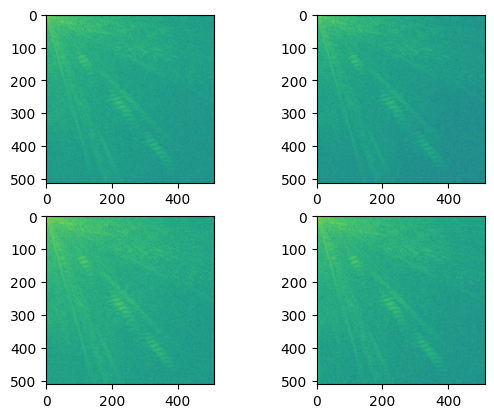

In [5]:
Y1 = dctn(X, type=1)
Y2 = dctn(X, type=2)
Y3 = dctn(X, type=3)
Y4 = dctn(X, type=4)
freq_db_1 = 20*np.log10(abs(Y1))
freq_db_2 = 20*np.log10(abs(Y2))
freq_db_3 = 20*np.log10(abs(Y3))
freq_db_4 = 20*np.log10(abs(Y4))

plt.subplot(221).imshow(freq_db_1)
plt.subplot(222).imshow(freq_db_2)
plt.subplot(223).imshow(freq_db_3)
plt.subplot(224).imshow(freq_db_4)
plt.show()

# Compactarea energiei. Compresie.

Putem profita de proprietatea compresiei energiei prin anularea frecvențelor DCT începând cu *bin*-ul `k` după care aplicăm transformata DCT inversă (similar cu tema anterioară):

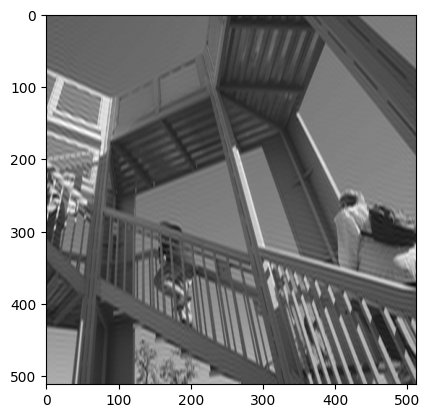

In [6]:
k = 120

Y_ziped = Y2.copy()
Y_ziped[k:] = 0
X_ziped = idctn(Y_ziped)

plt.imshow(X_ziped, cmap=plt.cm.gray)
plt.show()

# JPEG

Algoritmul de compresie JPEG are patru etape:

1. transformarea imaginii din pixeli RGB în Y'CbCr
2. aplicarea 2D-DCT pe blocuri disincte de 8x8 pixeli din imagine
3. cuantizarea în frecvență cu $Q$ dat de standardul JPEG
4. compresia rezultatului cu coduri Huffman

Unde matricea JPEG de cuantizare $Q$ este:
$$
Q =
\begin{bmatrix}
16 & 11 & 10 & 16 & 24 & 40 & 51 & 61 & \\
12 & 12 & 14 & 19 & 26 & 28 & 60 & 55 & \\
14 & 13 & 16 & 24 & 40 & 57 & 69 & 56 & \\
14 & 17 & 22 & 29 & 51 & 87 & 80 & 62 & \\
18 & 22 & 37 & 56 & 68 & 109 & 103 & 77 & \\
24 & 35 & 55 & 64 & 81 & 104 & 113 & 92 & \\
49 & 64 & 78 & 87 & 103 & 121 & 120 & 101\\
72 & 92 & 95 & 98 & 112 & 100 & 103 & 99\\
\end{bmatrix}
$$

Imaginea noastră de test este monocromă, deci nu necesită pasul 1, dar putem efectua o operație de *down-sampling* în preprocesare precum am prezentat la curs.

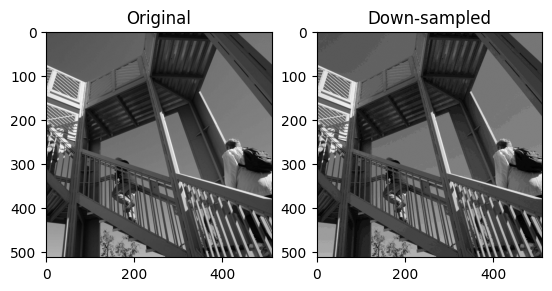

In [5]:
Q_down = 10

X_jpeg = X.copy()
X_jpeg = Q_down*np.round(X_jpeg/Q_down);

plt.subplot(121).imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(X_jpeg, cmap=plt.cm.gray)
plt.title('Down-sampled')
plt.show()

Pentru fiecare bloc de $8\times 8$ aplică DCT și cuantizare.

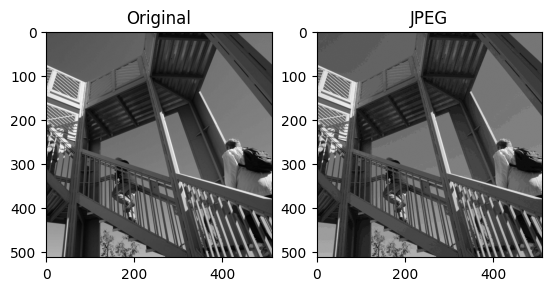

Componente în frecvență:210726
Componente în frecvență după cuantizare: 140638


In [6]:
Q_jpeg = [[16, 11, 10, 16, 24, 40, 51, 61],
          [12, 12, 14, 19, 26, 28, 60, 55],
          [14, 13, 16, 24, 40, 57, 69, 56],
          [14, 17, 22, 29, 51, 87, 80, 62],
          [18, 22, 37, 56, 68, 109, 103, 77],
          [24, 35, 55, 64, 81, 104, 113, 92],
          [49, 64, 78, 87, 103, 121, 120, 101],
          [72, 92, 95, 98, 112, 100, 103, 99]]

# Encoding
N1, N2 = X.shape
pad_vert = (-N1)%8
pad_oriz = (-N2)%8
Xp = np.pad(X, ((0, pad_vert), (0, pad_oriz)), mode="constant", constant_values=0)
N1, N2 = Xp.shape
y_jpeg = np.zeros((N1,N2))
y = np.zeros((N1, N2))
for i in range(N1//8):
    for j in range(N2//8):
        a, b = 8*i, 8*j
        x = X_jpeg[a:a+8, b:b+8]
        y[a:a+8, b:b+8] = dctn(x)
        y_jpeg[a:a+8, b:b+8] = Q_jpeg*np.round(y[a:a+8, b:b+8]/Q_jpeg)

# Decoding
x_jpeg = np.zeros((N1, N2))
for i in range(N1//8):
    for j in range(N2//8):
        a, b = 8*i, 8*j
        x_jpeg[a:a+8, b:b+8] = idctn(y_jpeg[a:a+8, b:b+8])

N1, N2 = X.shape
x_jpeg = x_jpeg[:N1, :N2]

# Results
y_nnz = np.count_nonzero(y)
y_jpeg_nnz = np.count_nonzero(y_jpeg)

plt.subplot(121).imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(x_jpeg, cmap=plt.cm.gray)
plt.title('JPEG')
plt.show()

print('Componente în frecvență:' + str(y_nnz) + 
      '\nComponente în frecvență după cuantizare: ' + str(y_jpeg_nnz))

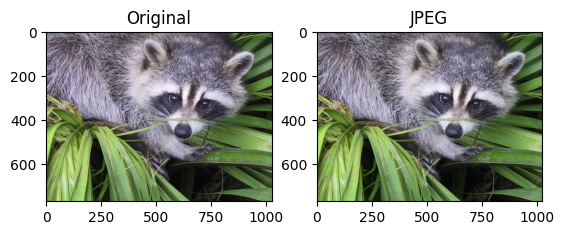

In [13]:
Q_jpeg = [[16, 11, 10, 16, 24, 40, 51, 61],
          [12, 12, 14, 19, 26, 28, 60, 55],
          [14, 13, 16, 24, 40, 57, 69, 56],
          [14, 17, 22, 29, 51, 87, 80, 62],
          [18, 22, 37, 56, 68, 109, 103, 77],
          [24, 35, 55, 64, 81, 104, 113, 92],
          [49, 64, 78, 87, 103, 121, 120, 101],
          [72, 92, 95, 98, 112, 100, 103, 99]]
Q_jpeg = np.asarray(Q_jpeg, dtype=np.float64)

def makeImage(Ch1, Ch2, Ch3):
    img = np.stack([Ch1, Ch2, Ch3], axis=-1)
    return np.clip(img, 0, 255).astype(np.uint8)

def YCbCr_transform(imgRGB):
    img = imgRGB.astype(np.float32)
    R, G, B = img[..., 0], img[..., 1], img[..., 2]
    
    Y  =  0.299 * R + 0.587 * G + 0.114 * B
    Cb = 128 - 0.168736 * R - 0.331264 * G + 0.5 * B
    Cr = 128 + 0.5 * R - 0.418688 * G - 0.081312 * B
    
    # plt.subplot(121).imshow(imgRGB)
    # plt.title('Original')
    # plt.subplot(122).imshow(img_ycrcb)
    # plt.title('Y\'CbCr')
    # plt.show()
    return makeImage(Y, Cb, Cr)

def RGB_transform(img_ycbcr):
    ycbcr = img_ycbcr.astype(np.float32)
    Y  = ycbcr[..., 0]
    Cb = ycbcr[..., 1] - 128.0
    Cr = ycbcr[..., 2] - 128.0

    R = Y + 1.402    * Cr
    G = Y - 0.344136 * Cb - 0.714136 * Cr
    B = Y + 1.772    * Cb
    
    return makeImage(R,G,B)

def jpg(X, Q_jpeg, s = 1.0):
    # Encoding
    N1, N2 = X.shape
    pad_vert = (-N1)%8
    pad_oriz = (-N2)%8
    Xp = np.pad(X, ((0, pad_vert), (0, pad_oriz)), mode="constant", constant_values=0)
    N1, N2 = Xp.shape
    y_jpeg = np.zeros((N1,N2))
    y = np.zeros((N1, N2))

    Qs = Q_jpeg * float(s)
    
    for i in range(N1//8):
        for j in range(N2//8):
            a, b = 8*i, 8*j
            x = X[a:a+8, b:b+8]
            y[a:a+8, b:b+8] = dctn(x)
            y_jpeg[a:a+8, b:b+8] = Qs*np.round(y[a:a+8, b:b+8]/Qs)

    # Decoding
    x_jpeg = np.zeros((N1, N2))
    for i in range(N1//8):
        for j in range(N2//8):
            a, b = 8*i, 8*j
            x_jpeg[a:a+8, b:b+8] = idctn(y_jpeg[a:a+8, b:b+8])

    N1, N2 = X.shape
    x_jpeg = x_jpeg[:N1, :N2]
    return x_jpeg, y, y_jpeg

def jpgColor(img, Q_jpeg):
    img_ycbcr = YCbCr_transform(img)
    Y = img_ycbcr[..., 0]
    Cb = img_ycbcr[..., 1]
    Cr = img_ycbcr[..., 2]
    
    Yjpeg, _, _ = jpg(Y, Q_jpeg)
    Cbjpeg, _, _ = jpg(Cb, Q_jpeg)
    Crjpeg, _, _ = jpg(Cr, Q_jpeg)
    
    img_ycbcr_jpeg = makeImage(Yjpeg, Cbjpeg, Crjpeg)
    
    return RGB_transform(img_ycbcr_jpeg)


img = datasets.face()
imgJPEG = jpgColor(img, Q_jpeg)

plt.subplot(121).imshow(img, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(imgJPEG, cmap=plt.cm.gray)
plt.title('JPEG')
plt.show()

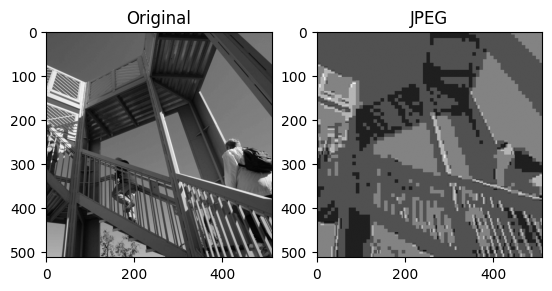

Componente în frecvență:250378
Componente în frecvență după cuantizare: 3910


In [18]:
def mse(a, b):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    return np.mean((a - b) ** 2)

def jpg_until_mse(X, Q_jpeg, mse_target, s_lo=0.1, s_hi=50.0, iters=20):
    x_lo, _, _ = jpg(X, Q_jpeg, s_lo)
    mse_lo = mse(X, x_lo)
    if mse_lo > mse_target:
        return x_lo, s_lo, mse_lo

    x_hi, _, _ = jpg(X, Q_jpeg, s_hi)
    mse_hi = mse(X, x_hi)
    tries = 0
    while mse_hi <= mse_target and tries < 10:
        s_hi *= 2.0
        x_hi, _, _ = jpg(X, Q_jpeg, s_hi)
        mse_hi = mse(X, x_hi)
        tries += 1

    best_s = s_lo
    best_x = x_lo
    best_m = mse_lo

    lo, hi = s_lo, s_hi
    for _ in range(iters):
        mid = (lo + hi) / 2.0
        x_mid, _, _ = jpg(X, Q_jpeg, mid)
        m_mid = mse(X, x_mid)

        if m_mid <= mse_target:
            best_s, best_x, best_m = mid, x_mid, m_mid
            lo = mid          
        else:
            hi = mid          

    return jpg(X, Q_jpeg, best_s)


mse_target = 1000
x_jpeg, y, y_jpeg = jpg_until_mse(X, Q_jpeg, mse_target)
plt.subplot(121).imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(x_jpeg, cmap=plt.cm.gray)
plt.title('JPEG')
plt.show()

y_nnz = np.count_nonzero(y)
y_jpeg_nnz = np.count_nonzero(y_jpeg)
print('Componente în frecvență:' + str(y_nnz) + 
      '\nComponente în frecvență după cuantizare: ' + str(y_jpeg_nnz))

In [14]:
SCRIPT_DIR = Path.cwd()

video_path = SCRIPT_DIR / "filmuletz.mp4"

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    print("Error: Could not open video file.")
    sys.exit(1)

fps = cap.get(cv2.CAP_PROP_FPS)
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out_path = SCRIPT_DIR / "filmuletz_jpeg.mp4"

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(str(out_path), fourcc, fps, (w, h))

if not writer.isOpened():
    print("Error: Could not open VideoWriter.")
    sys.exit(1)

while True:
    ret, frame = cap.read()

    if not ret:
        break

    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frameJPEG = jpgColor(frame_rgb, Q_jpeg)
    frameJPEG_bgr = cv2.cvtColor(frameJPEG, cv2.COLOR_RGB2BGR)
    
    writer.write(frameJPEG_bgr)


cap.release()
writer.release()
cv2.destroyAllWindows()

print("DONE COMPRESSING")

cap = cv2.VideoCapture(str(out_path))
if not cap.isOpened():
    print("Error: Could not open video file.")
    sys.exit(1)
    
while True:
    ret, frame = cap.read()

    if not ret:
        break

    cv2.imshow("Video", frame)

    # Press Q to quit
    if cv2.waitKey(25) & 0xFF == ord('q'):
        break

cap.release()
writer.release()
cv2.destroyAllWindows()


DONE COMPRESSING


# Sarcini

1. [6p] Completați algoritmul JPEG incluzând toate blocurile din imagine.

2. [4p] Extindeți la imagini color (incluzând transformarea din RGB în Y'CbCr).

3. [6p] Extindeți algoritmul pentru compresia imaginii până la un prag MSE impus de utilizator.

4. [4p] Extindeți algoritmul pentru compresie video. Demonstrați pe un clip scurt din care luați fiecare cadru și îl tratați ca pe o imagine.